### Kursbezeichnung:

Projekt: Programmierung mit Python (DLBFTPPP01)

### Aufgabenstellung 2:

Vergleich von Aktien

### Studiengang:

Softwareentwicklung

### Tutor

Dr. Aiko Walte

### Datum:

26.09.2026

### Verfasser:

Dustin Vetter

### Matrikelnummer

IU14110854

# Gliederung

1. Einleitung
2. Datenbeschaffung
3. Kursverläufe
4. Rendite
5. Risiko
6. Rendite und Risiko kombiniert
7. Diversifikationseffekt
8. Korrelationen
9. Schlussbetrachtung
10. Abbildungsverzeichnis
11. Literaturverzeichnis

# 1. Einleitung

- Aufgabenstellung 2 fordert den Vergleich der Finanzdaten mehrerer börsennotierter Unternehmen hinsichtlich Rendite, Risiko und Zusammenhängen
- Als Rahmenthema wird der aktuelle KI-Boom gewählt
- Die Kapitalflüsse in diesem Sektor wachsen rasant: OpenAI führt Berichten zufolge bereits Gespräche über eine Finanzierungsrunde mit einer Bewertung von über 1,2 Billionen US-Dollar (Dehari, 2026)
- Anlass, die Kursentwicklung bereits börsennotierter KI-Unternehmen im direkten Vergleich zu betrachten

## Untersuchte Unternehmen:

| Unternehmen | Ticker | Sektor | Kontinent |
|---|---|---|---|
| Nvidia | NVDA | Hardware | Nordamerika |
| ASML | ASML | Hardware | Europa |
| TSMC | TSM | Hardware | Asien |
| Palantir | PLTR | Software | Nordamerika |
| SAP | SAP | Software | Europa |
| Tencent | TCEHY | Software | Asien |

## Leitfragen: 

Unterscheiden sich Kursmuster von KI-nahen Unternehmen ...
- ... zwischen Hardware- und Software-Unternehmen?
- ... zwischen Unternehmen aus unterschiedlichen Kontinenten?

# 2. Datenbeschaffung

## 2.1 Rohdaten

- Datenquelle: Yahoo Finance über die Python Bibliothek `yfinance`
- tägliche Kurse vom 01.09.2021 bis 31.08.2026
- bereinigt von Aktiensplits und Dividenden
    - Aktiensplit: Aufteilung einer Aktie in mehrere günstigere Aktien (Wenke, 2018a)
    - Dividende: Gewinnausschüttung an die Aktionäre (Wenke, 2018b)
    - beides senkt den Kurs, ohne echten Wertverlust
    - Nvidia hatte z. B. einen 10:1 Aktiensplit im Juni 2024 (Erhard, 2024)

In [1]:
# Bibliotheken importieren
import yfinance
import pandas
import numpy
import plotly.express
import plotly.graph_objects

In [2]:
# Unternehmen mit Metadaten definieren
unternehmen = {
    'NVDA': {'name': 'Nvidia', 'sektor': 'Hardware', 'kontinent': 'Nordamerika'},
    'ASML': {'name': 'ASML', 'sektor': 'Hardware', 'kontinent': 'Europa'},
    'TSM':  {'name': 'TSMC', 'sektor': 'Hardware', 'kontinent': 'Asien'},
    'PLTR': {'name': 'Palantir', 'sektor': 'Software', 'kontinent': 'Nordamerika'},
    'SAP':  {'name': 'SAP', 'sektor': 'Software', 'kontinent': 'Europa'},
    'TCEHY': {'name': 'Tencent', 'sektor': 'Software', 'kontinent': 'Asien'},
}

In [3]:
# Liste der Ticker aus dem Dictionary holen
ticker_liste = list(unternehmen.keys())

ticker_liste

['NVDA', 'ASML', 'TSM', 'PLTR', 'SAP', 'TCEHY']

In [4]:
# Zeitraum festlegen
start_datum = '2021-09-01'
end_datum = '2026-08-31'

In [5]:
# Rohdaten herunterladen
rohdaten = yfinance.download(ticker_liste, start=start_datum, end=end_datum, auto_adjust=True);

[*********************100%***********************]  6 of 6 completed


In [6]:
# Rohdaten anzeigen
rohdaten

Price             Close                                                 \
Ticker             ASML        NVDA        PLTR         SAP      TCEHY   
Date                                                                     
2021-09-01   803.498352   22.342590   26.200001  137.997070  57.482929   
2021-09-02   821.731018   22.297785   26.510000  136.958237  56.423382   
2021-09-03   818.706421   22.742828   26.639999  137.739670  56.191883   
2021-09-07   822.198608   22.562626   26.700001  137.546600  59.735600   
2021-09-08   818.592163   22.241041   25.580000  134.889816  57.972645   
...                 ...         ...         ...         ...        ...   
2026-08-24  1740.130005  208.246979  175.889999  218.660004  57.090000   
2026-08-25  1744.160034  212.811874  172.729996  216.929993  56.549999   
2026-08-26  1745.640015  209.425659  177.500000  211.679993  56.459999   
2026-08-27  1735.010010  227.725174  185.929993  221.169998  56.889999   
2026-08-28  1696.160034  217.306839  186.289993  221.539993  57.959999   

Price                          High                                      ...  \
Ticker             TSM         ASML        NVDA        PLTR         SAP  ...   
Date                                                                     ...   
2021-09-01  110.742851   811.655733   22.597468   26.510000  139.256515  ...   
2021-09-02  111.046227   822.465621   22.493921   26.870001  137.592560  ...   
2021-09-03  113.969696   823.352791   22.885201   26.750000  137.895950  ...   
2021-09-07  114.640839   828.982112   22.798586   26.879999  138.732513  ...   
2021-09-08  112.057495   820.414491   22.510853   26.610001  135.864279  ...   
...                ...          ...         ...         ...         ...  ...   
2026-08-24  409.022705  1761.979980  215.349033  178.750000  220.089996  ...   
2026-08-25  416.293213  1769.989990  214.489989  179.869995  218.089996  ...   
2026-08-26  416.572449  1761.709961  213.361258  178.490005  212.320007  ...   
2026-08-27  426.156738  1751.780029  230.212396  186.860001  222.399994  ...   
2026-08-28  416.402893  1740.000000  229.003742  188.369995  222.960007  ...   

Price             Open                                      Volume             \
Ticker            PLTR         SAP      TCEHY         TSM     ASML       NVDA   
Date                                                                            
2021-09-01   26.459999  138.613004  56.067228  110.522213   581900  201767000   
2021-09-02   26.209999  137.500638  57.135685  111.184128   746800  187834000   
2021-09-03   26.490000  136.204430  55.906962  111.772491   698000  280532000   
2021-09-07   26.790001  138.557843  58.542493  114.567297   780900  198107000   
2021-09-08   26.600000  135.377048  59.610941  113.050376   714900  254434000   
...                ...         ...        ...         ...      ...        ...   
2026-08-24  177.389999  216.990005  56.330002  412.762672  1202000  135187300   
2026-08-25  176.630005  215.309998  56.500000  413.480751   808900  122309000   
2026-08-26  170.600006  208.580002  56.820000  417.330425   873500  179900000   
2026-08-27  178.750000  216.259995  56.990002  421.888191  1027200  298909800   
2026-08-28  184.949997  219.770004  58.020000  426.346219  1257700  195116400   

Price                                             
Ticker          PLTR      SAP    TCEHY       TSM  
Date                                              
2021-09-01  34417200   363500  8588600   8603900  
2021-09-02  38460100   211500  6234100   6866400  
2021-09-03  26609500   479200  4724700  10361400  
2021-09-07  35835100   383300  6740800   9739900  
2021-09-08  54394400   544800  7551000   7983300  
...              ...      ...      ...       ...  
2026-08-24  35115500  2117600  4355700  10645600  
2026-08-25  24558500  1849700  2948900   7049800  
2026-08-26  27924200  2821100  3090300   7449300  
2026-08-27  40739300  3292900  2525100  12749800  
2026-08-28  25060200  2318000  3567800   889

## Spalten der Rohdaten

- `Close`: Schlusskurs
- `High`: Höchstkurs des Tages
- `Low`: Tiefstkurs des Tages
- `Open`: Eröffnungskurs
- `Volume`: gehandelte Stückzahl des Tages

## Hinweis zur Datenquelle

- Die nicht-amerikanischen Unternehmen werden als American Depositary Receipt (ADR) gehandelt
- ADR sind die in den USA gehandelten Stellvertreter-Aktien in USD, die Kursbewegung folgt aber eng dem jeweiligen Heimatmarkt (Pöferlein, 2020)

## 2.2 Schlusskurse

- Von den fünf Spalten aus den Rohdaten wird nur `Close` weiterverwendet
- Ein Wert pro Tag und Unternehmen, immer zum gleichen Zeitpunkt (Börsenschluss)
- Alle Kennzahlen in den folgenden Kapiteln basieren auf der Veränderung von Schlusskurs zu Schlusskurs

In [7]:
# nur die Schlusskurse verwenden
# und wieder in die gleiche Reihenfolge wie ticker_liste bringen
schlusskurse = rohdaten['Close'][ticker_liste]

In [8]:
# Schlusskurse anzeigen
schlusskurse.head()

Ticker,NVDA,ASML,TSM,PLTR,SAP,TCEHY
Date,,,,,,
2021-09-01,22.342590,803.498352,110.742851,26.200001,137.997070,57.482929
2021-09-02,22.297785,821.731018,111.046227,26.510000,136.958237,56.423382
2021-09-03,22.742828,818.706421,113.969696,26.639999,137.739670,56.191883
2021-09-07,22.562626,822.198608,114.640839,26.700001,137.546600,59.735600
2021-09-08,22.241041,818.592163,112.057495,25.580000,134.889816,57.972645


In [9]:
# prüfen, ob Werte fehlen 
schlusskurse.isna().sum()

Ticker
NVDA     0
ASML     0
TSM      0
PLTR     0
SAP      0
TCEHY    0
dtype: int64

# 3. Kursverläufe

## 3.1 Absolute Schlusskurse

- Visualisierung der Schlusskurse aus Kapitel 2 in USD, wie sie an der Börse notiert wurden

In [10]:
# leere Figur erstellen
figur_rohkurse = plotly.graph_objects.Figure()

# Layout aktualisieren
figur_rohkurse.update_layout(
    title='Abbildung 1: Absolute Schlusskurse',
    xaxis_title='Datum',
    yaxis_title='Kurs in USD'
)

# Absolute Schlusskurse der Rohdaten als Liniendiagramm
for ticker in schlusskurse.columns:
    figur_rohkurse.add_trace(
        plotly.graph_objects.Scatter(
            x=schlusskurse.index,
            y=schlusskurse[ticker],
            mode='lines',
            name=unternehmen[ticker]['name']
        )
    )

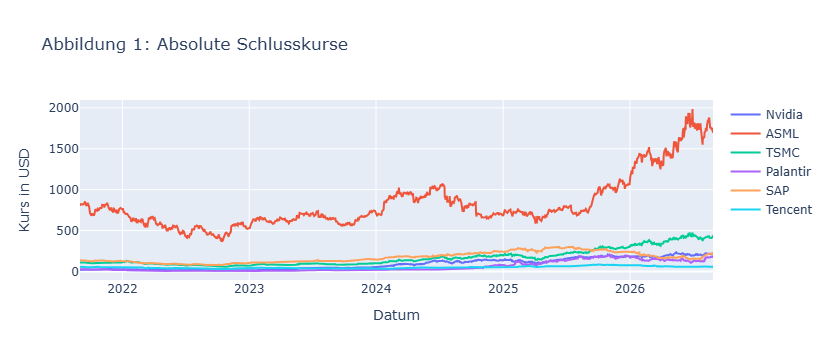

In [11]:
# Absolute Schlusskurse als Liniendiagramm anzeigen
figur_rohkurse.show()

Quelle: Eigene Darstellung

### Problem

- Die absoluten Kurse liegen weit auseinander (ASML ca. 1.700 USD, Tencent ca. 60 USD)
- Gleiche prozentuale Entwicklung sieht dadurch völlig unterschiedlich aus
    - Tencent 50 → 100 USD und ASML 500 → 1.000 USD: beide +100 %
- Lösung: Normalisierung

## 3.2 Normalisierte Schlusskurse

- Um die relative Wertentwicklung vergleichbar zu machen, werden alle Kurse am ersten Tag des Betrachtungszeitraums auf den Wert 100 gesetzt

In [12]:
# Normalisierte Schlusskurse berechnen
# ersten Tag auf 100 setzen
schlusskurse_normalisiert = schlusskurse / schlusskurse.iloc[0] * 100

# Normalisierte Schlusskurse anzeigen
schlusskurse_normalisiert

Ticker,NVDA,ASML,TSM,PLTR,SAP,TCEHY
Date,,,,,,
2021-09-01,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2021-09-02,99.799461,102.269160,100.273946,101.183204,99.247206,98.156762
2021-09-03,101.791368,101.892732,102.913818,101.679384,99.813474,97.754036
2021-09-07,100.984826,102.327355,103.519855,101.908397,99.673566,103.918851
2021-09-08,99.545491,101.878512,101.187114,97.633585,97.748319,100.851932
...,...,...,...,...,...,...
2026-08-24,932.062826,216.569206,369.344568,671.335856,158.452642,99.316442
2026-08-25,952.494188,217.070767,375.909784,659.274774,157.198984,98.377031
2026-08-26,937.338312,217.254959,376.161932,677.480896,153.394556,98.220463


In [13]:
# Leere Figur erzeugen
figur_normalisiert = plotly.graph_objects.Figure()

# Layout aktualisieren
figur_normalisiert.update_layout(
    title='Abbildung 2: Normalisierte Schlusskurse',
    xaxis_title='Datum',
    yaxis_title='Relative Kursentwicklung'
)

# Normalisierte Schlusskurse als Liniendiagramm
for ticker in schlusskurse_normalisiert.columns:
    figur_normalisiert.add_trace(
        plotly.graph_objects.Scatter(
            x=schlusskurse_normalisiert.index,
            y=schlusskurse_normalisiert[ticker],
            mode='lines',
            name=unternehmen[ticker]['name']
        )
    )

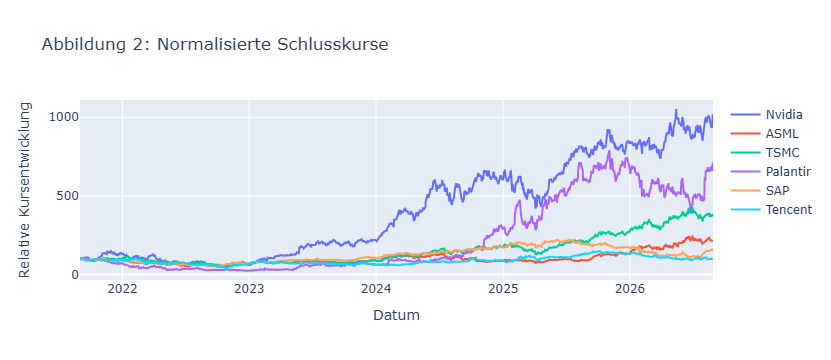

In [14]:
# Normalisierte Schlusskurse als Liniendiagramm anzeigen
figur_normalisiert.show()

Quelle: Eigene Darstellung

### Beobachtungen normalisierte Kursverläufe

- Nvidia (ca. +873 %) und Palantir (ca. +611 %) mit großem Abstand vorn
- Beide aus Nordamerika, aber je einmal Hardware und Software
- Die übrigen vier Unternehmen entwickeln sich deutlich flacher

## 3.3 Besondere Ereignisse

- Veröffentlichung von ChatGPT am 30. November 2022 (OpenAI, 2022)
- DeepSeek-Schock am 27. Januar 2025 (Wessel, 2025)
- Liberation Day am 02. April 2025 (tagesschau, 2025)
- Beginn vom Irankrieg am 28.02.2026 (tagesschau, 2026)

In [15]:
# Ereignisse notieren
ereignisse = [
    ('2022-11-30', 'Release ChatGPT', 20),
    ('2025-01-27', 'DeepSeek-Schock', 20),
    ('2025-04-02', 'Liberation-Day', 0),
    ('2026-02-28', 'Irankrieg', 20)
]

# Layout aktualisieren
figur_normalisiert.update_layout(
    title='Abbildung 3: Normalisierte Schlusskurse mit Ereignissen'
)

for datum, ereignis, text_versatz in ereignisse:
    # Linien einzeichnen
    figur_normalisiert.add_vline(x=datum, line_dash='dash', line_color='gray')

    # Linien beschriften
    figur_normalisiert.add_annotation(
        x=datum,
        y=schlusskurse_normalisiert.values.max(),
        text=ereignis,
        showarrow=False,
        yshift=text_versatz
    )

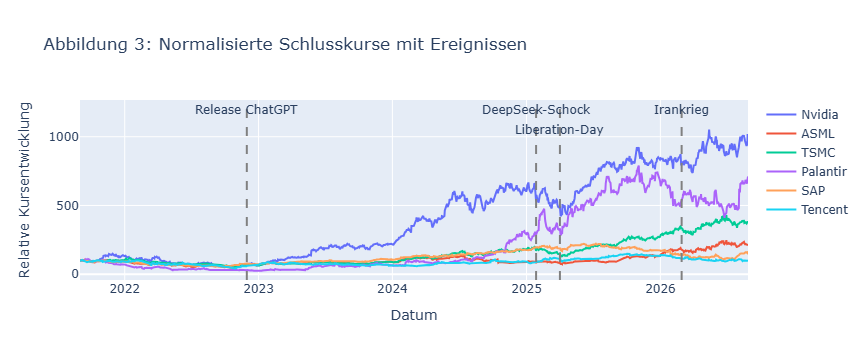

In [16]:
# Aktualisierte Figur anzeigen
figur_normalisiert.show()

Quelle: Eigene Darstellung

## 3.4 Kursveränderungen rund um besondere Ereignisse

- Vergleich des Schlusskurses am letzten Handelstag vor dem Ereignis mit dem Schlusskurs 5 Kalendertage danach
- Zeigt, wie stark jedes Unternehmen kurzfristig auf das jeweilige Ereignis reagiert hat

In [17]:
# Funktion zum Berechnen der Kursveränderung
def kursveraenderung_berechnen(ereignisdatum):
    davor = schlusskurse_normalisiert.asof(pandas.Timestamp(ereignisdatum) - pandas.Timedelta(days=1))
    danach = schlusskurse_normalisiert.asof(pandas.Timestamp(ereignisdatum) + pandas.Timedelta(days=5))
    return ((danach / davor - 1) * 100).round(2)

# Leeres DataFrame erstellen
kursveraenderungen = pandas.DataFrame()

# Kursveränderungen aller Ereignisse im DataFrame sammeln
for datum, ereignis, _ in ereignisse:
    kursveraenderungen[ereignis] = kursveraenderung_berechnen(datum)

# Kursveränderungen als Balkendiagramm
figur_ereignisse = plotly.express.bar(
    kursveraenderungen,
    barmode='group',
    title='Abbildung 4: Kursveränderungen rund um besondere Ereignisse',
    labels={'index': 'Unternehmen', 'value': 'Kursveränderungen in %', 'variable': 'Ereignisse'}
)

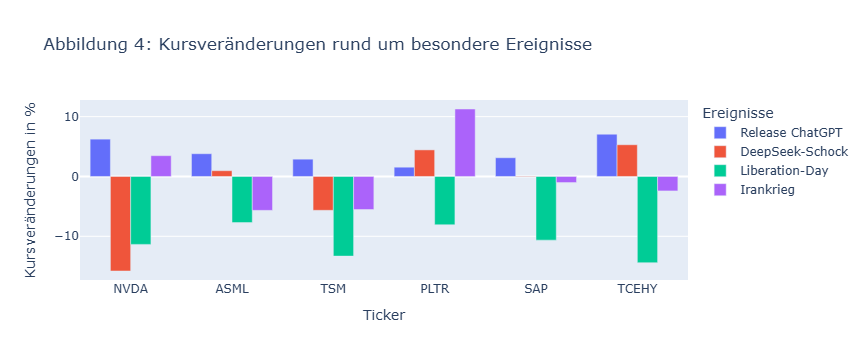

In [18]:
# Kursveränderungen rund um Ereignisse als Balkendiagramm anzeigen
figur_ereignisse.show()

Quelle: Eigene Darstellung

### Beobachtungen besondere Ereignisse

- ChatGPT: kaum Reaktion, alle leicht im Plus
- DeepSeek-Schock: fast nur Nvidia betroffen (ca. -16 %)
- Liberation Day: alle Unternehmen verlieren deutlich
- Irankrieg: nur die beiden nordamerikanischen Unternehmen im Plus

# 4. Rendite

- Rendite ist das Verhältnis von Ertrag zu eingesetztem Kapital (Schölisch, 2018)

## 4.1 Tägliche Rendite

- Prozentuale Kursveränderung von einem Tag zum nächsten Tag

In [19]:
# Tägliche Rendite berechnen
taegliche_rendite = schlusskurse.pct_change().dropna()

# Tägliche Rendite in % anzeigen
taegliche_rendite * 100

Ticker,NVDA,ASML,TSM,PLTR,SAP,TCEHY
Date,,,,,,
2021-09-02,-0.200539,2.269160,0.273946,1.183204,-0.752794,-1.843238
2021-09-03,1.995909,-0.368076,2.632660,0.490378,0.570563,-0.410289
2021-09-07,-0.792349,0.426549,0.588878,0.225230,-0.140170,6.306456
2021-09-08,-1.425298,-0.438634,-2.253423,-4.194760,-1.931552,-2.951263
2021-09-09,-0.725204,-0.523337,0.648125,2.150114,-0.715611,-2.841343
...,...,...,...,...,...,...
2026-08-24,-2.906113,-1.339752,-2.107655,-2.250752,-0.009141,-1.687618
2026-08-25,2.192059,0.231594,1.777532,-1.796579,-0.791188,-0.945877
2026-08-26,-1.591178,0.084853,0.067077,2.761538,-2.420136,-0.159151


In [20]:
# Tägliche Rendite als Boxplot
figur_taegliche_rendite = plotly.express.box(
    taegliche_rendite * 100,
    title='Abbildung 5: Tägliche Rendite',
    labels={'Ticker': 'Unternehmen', 'value': 'Tägliche Rendite in %'}
)

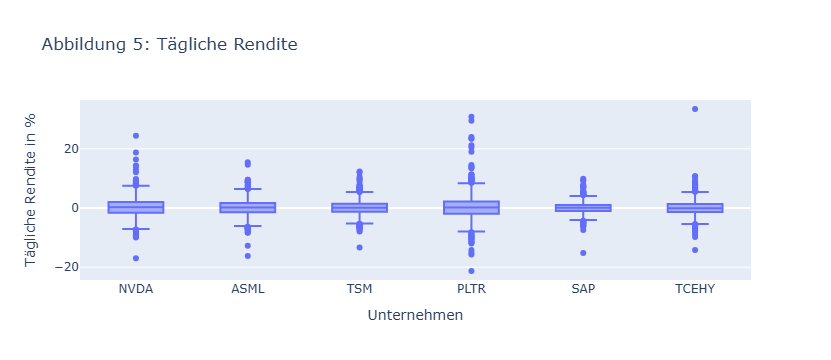

In [21]:
# Tägliche Rendite als Boxplot anzeigen
figur_taegliche_rendite.show()

Quelle: Eigene Darstellung

### Beobachtungen tägliche Rendite

- Palantir streut am stärksten (Tage mit über +30 % und -20 %)
- Nordamerika hat die meisten Ausreißer, nach oben wie nach unten
- Kein klares Muster zwischen Hardware und Software

## 4.2 Gesamtrendite

- Wertentwicklung über den gesamten Zeitraum (5 Jahre)

### Hinweis zu den Balkendiagrammen
- Farbe je Sektor: Hardware blau, Software orange
- Muster je Kontinent: ohne = Nordamerika, gestreift = Europa, kariert = Asien

In [22]:
# Variablen definieren, die sich in Balkendiagrammen wiederholen werden
# funktioniert nur, wenn sich die Reihenfolge der Schlusskurse nicht ändert

# Farben für einheitliche Darstellung nach Software/Hardware
farben_nach_sektor = ['blue', 'blue', 'blue', 'orange', 'orange', 'orange']

# Muster für einheitliche Darstellung nach Kontinent
muster_nach_kontinent = ['', '/', 'x', '', '/', 'x']

In [23]:
# Gesamtrendite berechnen
gesamtrendite = schlusskurse.iloc[-1] / schlusskurse.iloc[0] - 1

# Gesamtrendite als Balkendiagramm
figur_gesamtrendite = plotly.express.bar(
    x=gesamtrendite.index,
    y=gesamtrendite.values * 100,
    title='Abbildung 6: Gesamtrendite',
    labels={'x': 'Unternehmen', 'y': 'Gesamtrendite in %'}
)

# Farbe und Muster fürs Balkendiagramm
figur_gesamtrendite.update_traces(
    marker_color=farben_nach_sektor,
    marker_pattern_shape=muster_nach_kontinent
);

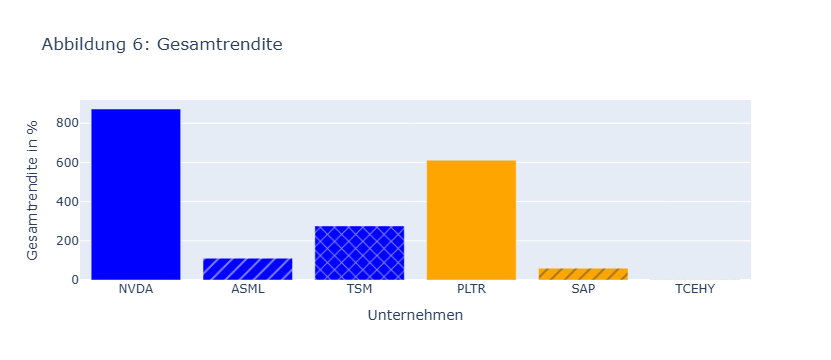

In [24]:
# Gesamtrendite als Balkendiagramm anzeigen
figur_gesamtrendite.show()

Quelle: Eigene Darstellung

### Beobachtungen Gesamtrendite

- Auf jedem Kontinent erzielt Hardware mehr Rendite als Software
- Größter Unterschied in Asien: TSMC ca. +276 %, Tencent ca. +1 %
- Kleinster Unterschied in Europa: ASML ca. +111 %, SAP ca. +61 %

## 4.3 Annualisierte Rendite

- Durchschnittliche Rendite pro Jahr
- Berücksichtigt den Zinseszins, deshalb nicht einfach Gesamtrendite ÷ 5

In [25]:
# Variablen für die Kennzahlen definieren

# 252 Handelstage pro Jahr
# Standard für US-/EU-Börsen
handelstage_pro_jahr = 252
print('Handelstage pro Jahr: ', handelstage_pro_jahr)

# Betrachtungszeitraum von 5 Jahren
anzahl_jahre = len(schlusskurse) / handelstage_pro_jahr
print('Anzahl an Jahren: ', anzahl_jahre)

Handelstage pro Jahr:  252
Anzahl an Jahren:  4.972222222222222


In [26]:
# Annualisierte Rendite berechnen
# mit Zinseszins
annualisierte_rendite = (1 + gesamtrendite) ** (1 / anzahl_jahre) - 1

# Annualisierte Rendite als Balkendiagramm
figur_annualisierte_rendite = plotly.express.bar(
    x=annualisierte_rendite.index,
    y=annualisierte_rendite.values * 100,
    title='Abbildung 7: Annualisierte Rendite',
    labels={'x': 'Unternehmen', 'y': 'Annualisierte Rendite in %'}
)

# Farbe und Muster fürs Balkendiagramm
figur_annualisierte_rendite.update_traces(
    marker_color=farben_nach_sektor,
    marker_pattern_shape=muster_nach_kontinent
);

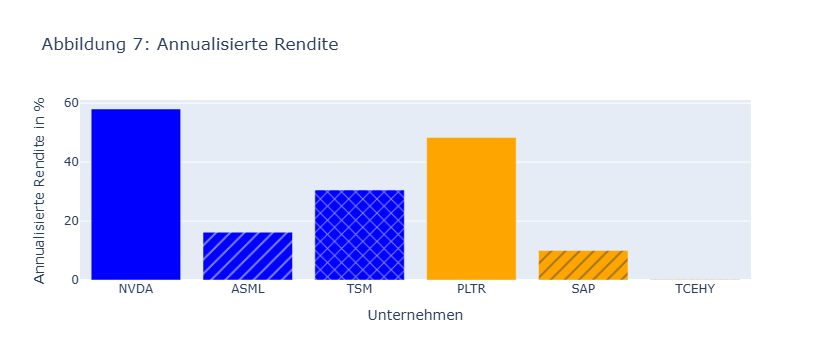

In [27]:
# Annualisierte Rendite als Balkendiagramm anzeigen
figur_annualisierte_rendite.show()

Quelle: Eigene Darstellung

### Beobachtungen annualisierte Rendite

- Nordamerika vorne: Nvidia ca. 58 % p. a., Palantir ca. 48 % p. a.
- Europa eher hinten: ASML ca. 16 %, SAP ca. 10 %
- Asien gespalten: TSMC ca. 31 %, Tencent ca. 0 %
- Hardware zwischen ca. 16 % und 58 % p. a.
- Software zwischen ca. 0 % und 48 % p. a.

# 5. Risiko

- Risiko wird aus zwei Blickwinkeln betrachtet
    - **Volatilität**: Wie stark schwankt die Aktie?
    - **Maximum Drawdown**: Wie tief kann sie fallen?

## 5.1 Tägliche Volatilität

- Volatilität misst die Schwankungsbreite der Rendite (Kill, 2020b)
- Tägliche Volatilität berechnet die Standardabweichung der täglichen Renditen (Kill, 2020b)
- es wird nur die Stärke der Schwankungen gemessen, nicht die Richtung
- je höher die Volatilität, desto höher das Risiko

In [28]:
# Tägliche Volatilität berechnen
taegliche_volatilitaet = taegliche_rendite.std()

# Tägliche Volatilität als Balkendiagramm
figur_taegliche_volatilitaet = plotly.express.bar(
    x=taegliche_volatilitaet.index,
    y=taegliche_volatilitaet.values * 100,
    title='Abbildung 8: Tägliche Volatilität',
    labels={'x': 'Unternehmen', 'y': 'Tägliche Volatilität in %'}
)

# Farbe und Muster fürs Balkendiagramm
figur_taegliche_volatilitaet.update_traces(
    marker_color=farben_nach_sektor,
    marker_pattern_shape=muster_nach_kontinent
);

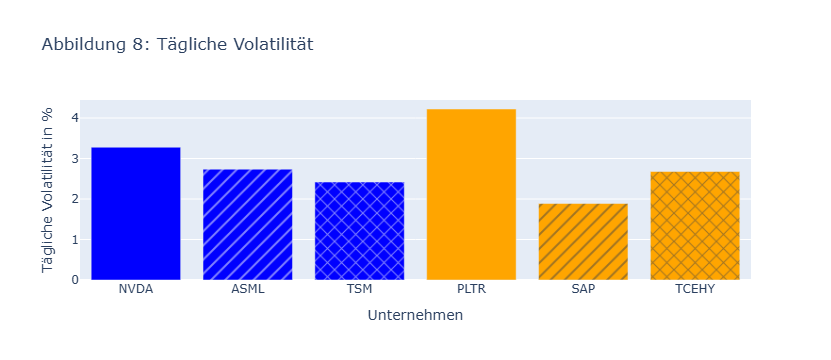

In [29]:
# Tägliche Volatilität als Balkendiagramm anzeigen
figur_taegliche_volatilitaet.show()

Quelle: Eigene Darstellung

### Beobachtungen tägliche Volatilität

- Nordamerika schwankt am stärksten (Palantir ca. 4,2 %, Nvidia ca. 3,3 % pro Tag)
- Hardware enger beieinander (ca. 2,4 % bis 3,3 %) als Software (ca. 1,9 % bis 4,2 %)
- SAP ist das einzige Software-Unternehmen, das weniger schwankt als das Hardware-Unternehmen vom selben Kontinent

## 5.2 Annualisierte Volatilität

- Tägliche Volatilität hochgerechnet aufs Jahr (Kill, 2020a)

In [30]:
# Annualisierte Volatilität berechnen
annualisierte_volatilitaet = taegliche_volatilitaet * numpy.sqrt(handelstage_pro_jahr)

# Annualisierte Volatilität als Balkendiagramm
figur_annualisierte_volatilitaet = plotly.express.bar(
    x=annualisierte_volatilitaet.index,
    y=annualisierte_volatilitaet.values * 100,
    title='Abbildung 9: Annualisierte Volatilität',
    labels={'x': 'Unternehmen', 'y': 'Annualisierte Volatilität in %'}
)

# Farbe und Muster fürs Balkendiagramm
figur_annualisierte_volatilitaet.update_traces(
    marker_color=farben_nach_sektor,
    marker_pattern_shape=muster_nach_kontinent
);

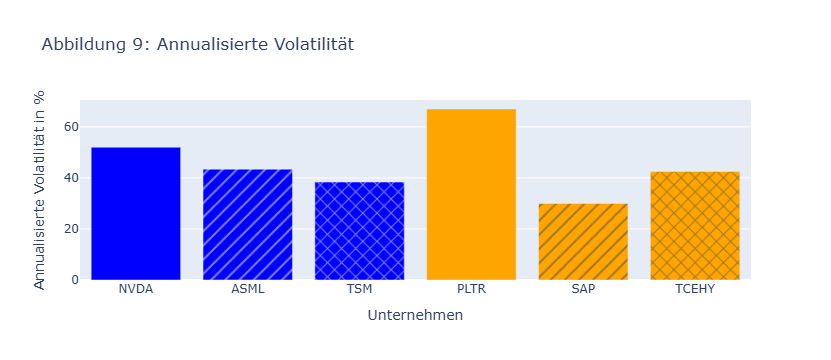

In [31]:
# Annualisierte Volatilität als Balkendiagramm anzeigen
figur_annualisierte_volatilitaet.show()

Quelle: Eigene Darstellung

### Beobachtungen annualisierte Volatilität

- Gleiche Reihenfolge wie bei der täglichen Volatilität
- Hardware enger beieinander (ca. 38 % bis 52 % p. a.) als Software (ca. 30 % bis 67 % p. a.)
- Nordamerika hat die höchsten Rendite, aber auch das höchste Risiko

## 5.3 Maximum Drawdown

- Zeigt den größten prozentualen Einbruch zwischen einem Höchststand und dem nachfolgenden Tiefpunkt (Wenke, 2020)
- Zeigt, wie viel ein Anleger im schlimmsten Fall zwischenzeitlich verloren hätte

In [32]:
# 1. Kumulierte Wertentwicklung berechnen
kumulierte_wertentwicklung = (1 + taegliche_rendite).cumprod()

# Kumulierte Wertentwicklung anzeigen
kumulierte_wertentwicklung

Ticker,NVDA,ASML,TSM,PLTR,SAP,TCEHY
Date,,,,,,
2021-09-02,0.997995,1.022692,1.002739,1.011832,0.992472,0.981568
2021-09-03,1.017914,1.018927,1.029138,1.016794,0.998135,0.977540
2021-09-07,1.009848,1.023274,1.035199,1.019084,0.996736,1.039189
2021-09-08,0.995455,1.018785,1.011871,0.976336,0.977483,1.008519
2021-09-09,0.988236,1.013453,1.018429,0.997328,0.970488,0.979864
...,...,...,...,...,...,...
2026-08-24,9.320628,2.165692,3.693446,6.713359,1.584526,0.993164
2026-08-25,9.524942,2.170708,3.759098,6.592748,1.571990,0.983770
2026-08-26,9.373383,2.172550,3.761619,6.774809,1.533946,0.982205


In [33]:
# 2. Kumuliertes Maximum berechnen
kumuliertes_maximum = kumulierte_wertentwicklung.cummax()

# Kumuliertes Maximum anzeigen
kumuliertes_maximum

Ticker,NVDA,ASML,TSM,PLTR,SAP,TCEHY
Date,,,,,,
2021-09-02,0.997995,1.022692,1.002739,1.011832,0.992472,0.981568
2021-09-03,1.017914,1.022692,1.029138,1.016794,0.998135,0.981568
2021-09-07,1.017914,1.023274,1.035199,1.019084,0.998135,1.039189
2021-09-08,1.017914,1.023274,1.035199,1.019084,0.998135,1.039189
2021-09-09,1.017914,1.023274,1.035199,1.019084,0.998135,1.039189
...,...,...,...,...,...,...
2026-08-24,10.527087,2.472775,4.300885,7.907633,2.221787,1.501709
2026-08-25,10.527087,2.472775,4.300885,7.907633,2.221787,1.501709
2026-08-26,10.527087,2.472775,4.300885,7.907633,2.221787,1.501709


In [34]:
# 3. Drawdown berechnen
drawdown = (kumulierte_wertentwicklung - kumuliertes_maximum) / kumuliertes_maximum

# Drawdown anzeigen
drawdown

Ticker,NVDA,ASML,TSM,PLTR,SAP,TCEHY
Date,,,,,,
2021-09-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-09-03,0.000000,-0.003681,0.000000,0.000000,0.000000,-0.004103
2021-09-07,-0.007923,0.000000,0.000000,0.000000,-0.001402,0.000000
2021-09-08,-0.022064,-0.004386,-0.022534,-0.041948,-0.020690,-0.029513
2021-09-09,-0.029156,-0.009597,-0.016199,-0.021348,-0.027698,-0.057088
...,...,...,...,...,...,...
2026-08-24,-0.114605,-0.124185,-0.141236,-0.151028,-0.286824,-0.338644
2026-08-25,-0.095197,-0.122157,-0.125971,-0.166281,-0.292466,-0.344900
2026-08-26,-0.109594,-0.121412,-0.125385,-0.143257,-0.309589,-0.345942


In [35]:
# 4. Maximum Drawdown berechnen
maximum_drawdown = drawdown.min()

# Maximum Drawdown als Balkendiagramm
figur_maximum_drawdown = plotly.express.bar(
    x=maximum_drawdown.index,
    y=maximum_drawdown.values * 100,
    title='Abbildung 10: Maximum Drawdown',
    labels={'x': 'Unternehmen', 'y': 'Maximum Drawdown in %'}
)

# Farbe und Muster fürs Balkendiagramm
figur_maximum_drawdown.update_traces(
    marker_color=farben_nach_sektor,
    marker_pattern_shape=muster_nach_kontinent
);

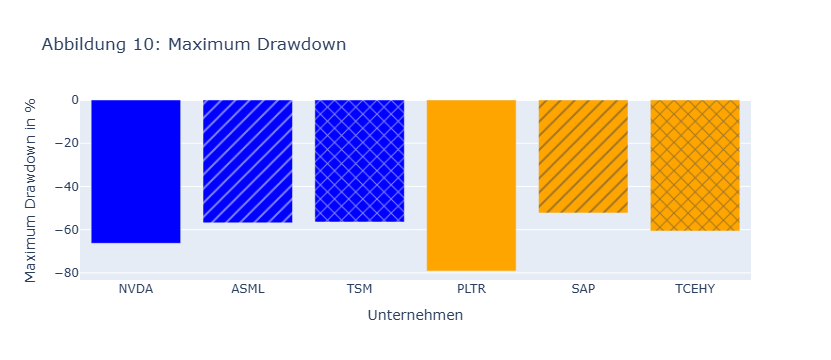

In [36]:
# Maximum Drawdown als Balkendiagramm anzeigen
figur_maximum_drawdown.show()

Quelle: Eigene Darstellung

### Beobachtungen Maximum Drawdown

- Gleiches Muster wie bei der Volatilität: Palantir fällt am tiefsten (ca. -79 %), SAP am wenigsten (ca. -52 %)
- Nordamerika mit den tiefsten Einbrüchen (Palantir ca. -79 %, Nvidia ca. -66 %)
- Hardware enger beieinander (ca. -56 % bis -66 %) als Software (ca. -52 % bis -79 %)

# 6. Rendite und Risiko kombiniert

- Kapitel 4 und 5 betrachten Rendite und Risiko getrennt
- Eine hohe Rendite ist nur dann gut, wenn das Risiko dafür angemessen ist
- Zwei Herangehensweisen
    - **Sharpe Ratio**: Kombiniert Rendite und Risiko zu einer Zahl
    - **Risiko-Rendite-Diagramm**: Beide Zahlen gleichzeitig sichtbar machen

## 6.1 Sharpe Ratio

- Verhältnis von Rendite zu eingegangenem Risiko (Kill, 2019)
- Zeigt, wie gut das Risiko durch zusätzliche Rendite vergütet wurde
- Zur Vereinfachung wird ein risikofreier Zins von 3 % angenommen

In [37]:
# Sharpe Ratio berechnen
# Annahme: risikofreier Zins = 3 %
sharpe_ratio = (annualisierte_rendite - 0.03) / annualisierte_volatilitaet

# Sharpe Ratio anzeigen
sharpe_ratio

# Sharpe Ratio als Balkendiagramm
figur_sharpe_ratio = plotly.express.bar(
    x=sharpe_ratio.index,
    y=sharpe_ratio.values,
    title='Abbildung 11: Sharpe Ratio',
    labels={'x': 'Unternehmen', 'y': 'Sharpe Ratio'}
)

# Farbe und Muster fürs Balkendiagramm
figur_sharpe_ratio.update_traces(
    marker_color=farben_nach_sektor,
    marker_pattern_shape=muster_nach_kontinent
);

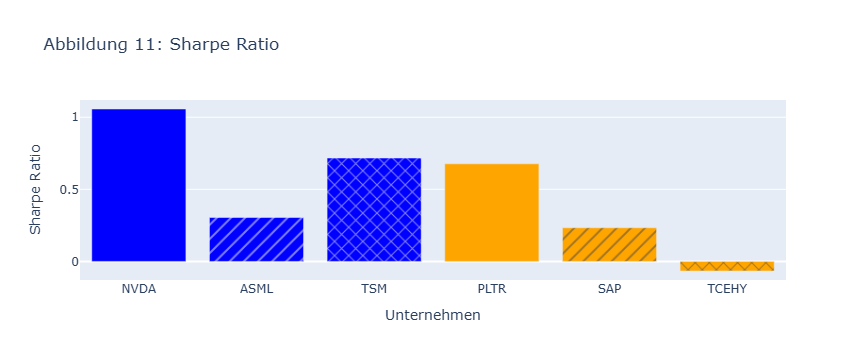

In [38]:
# Sharpe Ratio als Balkendiagramm anzeigen
figur_sharpe_ratio.show()

Quelle: Eigene Darstellung

### Beobachtungen Sharpe Ratio

- Auf jedem Kontinent hat Hardware die bessere Sharpe Ratio
- Nvidia mit dem besten Verhältnis (ca. 1,06), Tencent als einziges negativ (ca. -0,07)
- Palantir trotz höherer Rendite hinter TSMC, weil das Risiko deutlich höher ist

## 6.2 Risiko-Rendite-Diagramm

- Sharpe Ratio verdichtet Rendite und Risiko zu einer einzigen Kennzahl
    - zeigt aber nicht, auf welchem Rendite- und Risikoniveau ein Unternehmen tatsächlich liegt
- Risiko-Rendite-Diagramm macht beide Dimensionen getrennt sichtbar
    - Zwei Unternehmen mit ähnlicher Sharpe Ratio können an unterschiedlichen Punkten liegen
    - etwa niedrige Rendite bei niedrigem Risiko im Vergleich zu hoher Rendite bei hohem Risiko

In [39]:
# Farben festlegen
sektor_farben = {
    'Hardware': 'blue',
    'Software': 'orange'
}

# Formen festlegen
kontinent_formen = {
    'Nordamerika': 'circle',
    'Europa': 'triangle-up',
    'Asien': 'square'
}

In [40]:
# Leere Figur erstellen
figur_risiko_rendite = plotly.graph_objects.Figure()

# Layout aktualisieren
figur_risiko_rendite.update_layout(
    title='Abbildung 12: Risiko-Rendite-Diagramm',
    xaxis_title='Annualisierte Volatilität in %',
    yaxis_title='Annualisierte Rendite in %'
)

# Risiko-Rendite als Streudiagramm
for ticker in annualisierte_volatilitaet.index:
    sektor = unternehmen[ticker]['sektor']
    kontinent = unternehmen[ticker]['kontinent']
    figur_risiko_rendite.add_trace(
        plotly.graph_objects.Scatter(
            x=[annualisierte_volatilitaet[ticker] * 100],
            y=[annualisierte_rendite[ticker] * 100],
            mode='markers+text',
            text=unternehmen[ticker]['name'],
            textposition='bottom center',
            marker=dict(size=14, color=sektor_farben[sektor], symbol=kontinent_formen[kontinent]),
            name=ticker
        )
    )

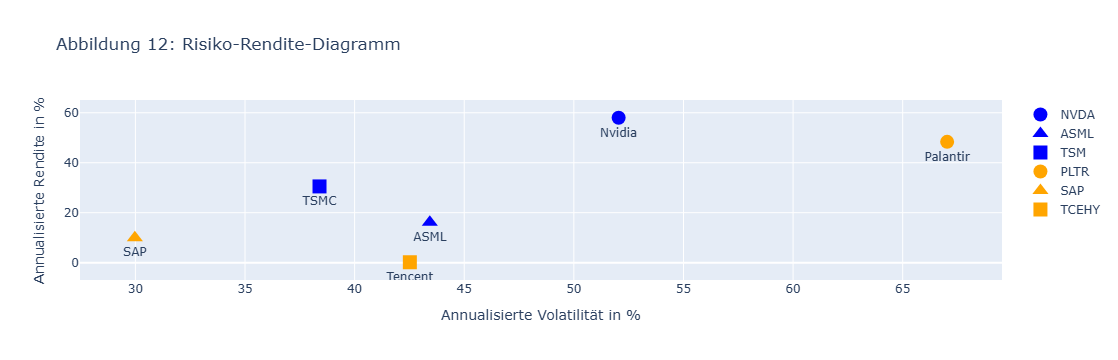

In [41]:
# Risiko-Rendite als Streudiagramm anzeigen
figur_risiko_rendite.show()

Quelle: Eigene Darstellung

### Beobachtungen Risiko-Rendite-Diagramm

- Hardware liegt enger beieinander, Software weit verstreut
- Nordamerika und Europa ähnlich bei der Rendite
- Asien ähnlich beim Risiko

# 7. Diversifikationseffekt

- Bisher wurde jede Aktie einzeln betrachtet
- Was passiert, wenn man alle sechs kombiniert?
- Diversifikation bedeutet eine Zusammenstellung mehrerer Aktien mit dem Ziel, das Gesamtrisiko zu senken (Kill, 2020c)
    - genauer: eine naive Diversifikation, also alle sechs Aktien zu gleichen Teilen (je 1/6)
- Diversifikationseffekt vergleicht die Volatilität des Portfolios mit der durchschnittlichen Volatilität der Einzelaktien

In [42]:
# 1. Durchschnittliche annualisierte Einzelvolatilität berechnen
durchschnittliche_annualisierte_einzelvolatilitaet = annualisierte_volatilitaet.mean()

# Durchschnittliche annualisierte Einzelvolatilität anzeigen
durchschnittliche_annualisierte_einzelvolatilitaet

np.float64(0.4556538366692373)

In [43]:
# 2. Tägliche Rendite vom Portfolio berechnen
portfolio_taegliche_rendite = taegliche_rendite.mean(axis=1)

# Tägliche Rendite vom Portfolio anzeigen
portfolio_taegliche_rendite

Date
2021-09-02    0.001550
2021-09-03    0.008185
2021-09-07    0.011024
2021-09-08   -0.021992
2021-09-09   -0.003345
                ...   
2026-08-24   -0.017168
2026-08-25    0.001113
2026-08-26   -0.002095
2026-08-27    0.034040
2026-08-28   -0.011435
Length: 1252, dtype: float64

In [44]:
# 3. Tägliche Volatilität vom Portfolio berechnen
portfolio_taegliche_volatilitaet = portfolio_taegliche_rendite.std()

# Tägliche Volatilität vom Portfolio anzeigen
portfolio_taegliche_volatilitaet

np.float64(0.02062008387267215)

In [45]:
# 4. Annualisierte Volatilität vom Portfolio berechnen
portfolio_annualisierte_volatilitaet = portfolio_taegliche_volatilitaet * numpy.sqrt(handelstage_pro_jahr)

# Annualisierte Volatilität vom Portfolio berechnen
portfolio_annualisierte_volatilitaet

np.float64(0.327333683642305)

In [46]:
# 5. Diversifikationseffekt berechnen
diversifikationseffekt = durchschnittliche_annualisierte_einzelvolatilitaet - portfolio_annualisierte_volatilitaet

diversifikationseffekt

np.float64(0.12832015302693234)

In [47]:
# leere Figur erstellen
figur_diversifikation = plotly.graph_objects.Figure()

# Layout aktualisieren
figur_diversifikation.update_layout(
    title='Abbildung 13: Diversifikationseffekt',
    xaxis_title='Unternehmen',
    yaxis_title='Annualisierte Volatilität in %'
)

# Daten als Balken abbilden
figur_diversifikation.add_trace(
    plotly.graph_objects.Bar(
        x=list(annualisierte_volatilitaet.index) + ['Portfolio (alle 6)'],
        y=list(annualisierte_volatilitaet * 100) + [portfolio_annualisierte_volatilitaet * 100]
    )
)

# Horizontale Linie hinzufügen
figur_diversifikation.add_hline(
    y=durchschnittliche_annualisierte_einzelvolatilitaet * 100,
    line_dash='dash',
    line_color='gray',
    annotation_text=f'Ø Einzelaktien: ca. {durchschnittliche_annualisierte_einzelvolatilitaet * 100:.1f} %'
)

# Beschriftung Portfolio hinzufügen
figur_diversifikation.add_annotation(
    x='Portfolio (alle 6)',
    y=portfolio_annualisierte_volatilitaet * 100,
    text=f'ca. -{diversifikationseffekt * 100:.1f} PP',
    ax=0,
    ay=-10
)

# Farbe und Muster fürs Balkendiagramm
figur_diversifikation.update_traces(
    marker_color=farben_nach_sektor + ['green'],
    marker_pattern_shape=muster_nach_kontinent + ['']
);

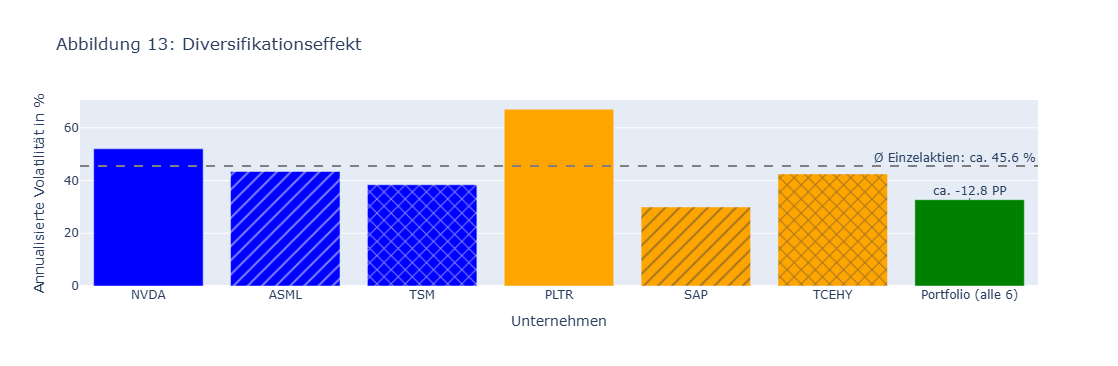

In [48]:
# Diversifikationseffekt als Balkendiagramm anzeigen
figur_diversifikation.show()

Quelle: Eigene Darstellung

### Beobachtungen Diversifikationseffekt

- Portfolio schwankt mit ca. 33 % p. a. deutlich weniger als die Einzelaktien im Schnitt (ca. 46 %)
- Das Risiko sinkt damit um rund 28 % bzw. 12,8 PP
- SAP allein (ca. 30 %) schwankt noch weniger als das Portfolio

# 8. Korrelationen

- Das Portfolio schwankt weniger als die Einzelaktien im Durchschnitt
- Der Grund liegt darin, wie sich die Aktien gemeinsam bewegen
- Korrelation beschreibt, wie stark sich die täglichen Renditen zweier Aktien gemeinsam bewegen (Kill, 2018)

In [49]:
# Korrelationsmatrix berechnen
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
korrelationsmatrix = taegliche_rendite.corr()

# Korrelationsmatrix anzeigen
korrelationsmatrix

Ticker,NVDA,ASML,TSM,PLTR,SAP,TCEHY
Ticker,,,,,,
NVDA,1.000000,0.654914,0.683388,0.473508,0.385012,0.250040
ASML,0.654914,1.000000,0.707392,0.376972,0.392285,0.317902
TSM,0.683388,0.707392,1.000000,0.380121,0.353199,0.292982
PLTR,0.473508,0.376972,0.380121,1.000000,0.372048,0.247443
SAP,0.385012,0.392285,0.353199,0.372048,1.000000,0.243475
TCEHY,0.250040,0.317902,0.292982,0.247443,0.243475,1.000000


In [50]:
# Korrelationen als Heatmap
figur_korrelation = plotly.express.imshow(
    korrelationsmatrix,
    zmin=-1,
    zmax=1,
    text_auto='.2f',
    title='Abbildung 14: Korrelationen',
)

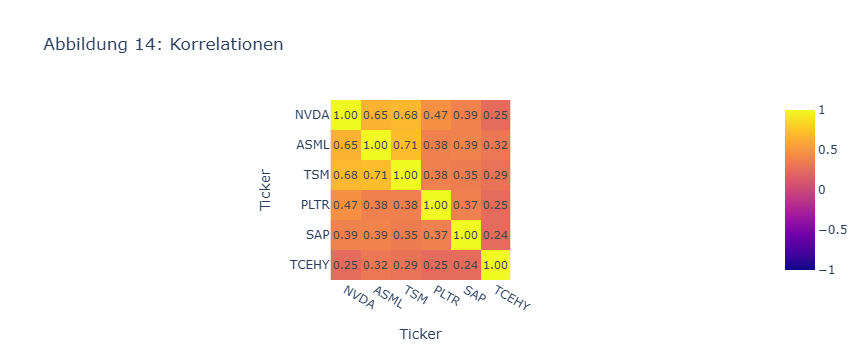

In [51]:
# Korrelation als Heatmap anzeigen
figur_korrelation.show()

Quelle: Eigene Darstellung

### Beobachtungen Korrelationen: Sektor

- Hardware korreliert stark (0,65 bis 0,71)
    - Mögliche Ursache: gemeinsame Lieferkette (Rzeszucinski, 2026)
- Software korreliert kaum (0,24 bis 0,37)
    - Mögliche Ursache: unterschiedliche Geschäftsmodelle und Märkte

### Beobachtungen Korrelationen: Kontinent

- Gleicher Kontinent korreliert nur schwach bis mittel (Nordamerika 0,47, Europa 0,39, Asien 0,29)
- Stärkste Korrelationen über Kontinente hinweg (ASML, Nvidia, TSMC)
- Tencent korreliert mit allen am schwächsten (0,24 bis 0,32)

### Zusammenhang mit dem Diversifikationseffekt

- Alle Korrelationen sind positiv, aber deutlich kleiner als 1
- Die Aktien bewegen sich nicht im Gleichschritt, Schwankungen gleichen sich teilweise aus
- Dadurch sinkt das Gesamtrisiko im Portfolio

# 9. Schlussbetrachtung

## 9.1 Kritische Reflexion

### Datenbasis

- Nur sechs Unternehmen (drei pro Sektor, zwei pro Kontinent): Ergebnisse sind nur Hinweise, keine allgmeingültigen Aussagen zum KI-Boom
- Survivorship Bias: nur heute erfolgreiche Unternehmen betrachtet
- Grenze zwischen reinen Hardware- und Software-Firmen verschwimmt
- kein Vergleich mit einem Marktindex wie z. B. S&P 500 oder MSCI World

### Methodische Vereinfachungen

- Die Sharpe Ratio wurde nicht mit dem realen risikofreien Zins berechnet
- ein anderer Start- oder Endzeitpunkt könnte zu anderen Ergebnissen führen, betrifft besonders die volatileren Kurse

### Persönliche Erfahrungen

- Sortierung der Unternehmen, Einsatz von Farben und Mustern hätte man früher machen müssen
- bessere Visualisierung hat zu neuen Blickwinkeln und besseren Auswertungen geführt

## 9.2 Verwendung von KI

- Claude Opus 5.5
- Einsatzbereiche
    - Fehlersuche im Python-Code
    - Recherche zu Python-Bibliotheken
    - Feedback zur Struktur des Notebooks
    - Erklärung von finanz-mathematischen Fachbegriffen
    - Umformulieren von Texten
    - Tippfehler finden

## 9.3 Fazit

> Unterscheiden sich Kursmuster von KI-nahen Unternehmen ...
> - ... zwischen Hardware- und Software-Unternehmen?

**Ja, Hardware-Unternehmen verhalten sich deutlich einheitlicher**
- Rendite: Hardware durchweg positiv (zwischen ca. 16 % und 58 % p. a.), Software zwischen ca. 0 % und 48 % p. a.
- Volatilität: Hardware dichter zusammen (ca. 38 % bis 52 % p. a.), Software weiter auseinander (ca. 30 % bis 67 % p. a.)
- Sharpe Ratio: Auf jedem Kontinent schneidet Hardware besser ab
- Korrelation: Hardware 0,65 bis 0,71, Software nur 0,24 bis 0,37

> Unterscheiden sich Kursmuster von KI-nahen Unternehmen ...
> - ... zwischen Unternehmen aus unterschiedlichen Kontinenten?

**Teilweise, der Kontinent spielt eine untergeordnete Rolle**
- Korrelation eines Kontinents nur 0,29 bis 0,47
- Stärkste Zusammenhänge über Kontinente hinweg (ASML, Nvidia, TSMC)
- Ausnahme: Einzelne Ereignisse wie der Irankrieg wirkten teils regional

## 9.4 Ausblick

- OpenAI, Anthropic und Mistral AI haben den KI-Hype maßgeblich mitausgelöst, sind jedoch (Stand heute) nicht börsennotiert und konnten daher nicht in den Vergleich einbezogen werden
- Sobald eines dieser Unternehmen an die Börse geht, wäre ein erneuter Vergleich interessant
- Insbesondere, ob sich das Lieferketten-Cluster dann auch auf Software-Anbieter ausweitet

# 10. Abbildungsverzeichnis

- Abbildung 1: Absolute Schlusskurse
- Abbildung 2: Normalisierte Schlusskurse
- Abbildung 3: Normalisierte Schlusskurse mit Ereignissen
- Abbildung 4: Kursveränderungen rund um besondere Ereignisse
- Abbildung 5: Tägliche Rendite
- Abbildung 6: Gesamtrendite
- Abbildung 7: Annualisierte Rendite
- Abbildung 8: Tägliche Volatilität
- Abbildung 9: Annualisierte Volatilität
- Abbildung 10: Maximum Drawdown
- Abbildung 11: Sharpe Ratio
- Abbildung 12: Risiko-Rendite-Diagramm
- Abbildung 13: Diversifikationseffekt
- Abbildung 14: Korrelationen

# 11. Literaturverzeichnis

- Dehari, L. (16. September 2026). *OpenAI erwägt wohl neue Finanzierungsrunde vor Börsengang.* https://www.handelsblatt.com/technik/ki/kuenstliche-intelligenz-openai-erwaegt-wohl-neue-finanzierungsrunde-vor-boersengang/100254901.html
- Erhard, A. (7. Juni 2024). *Aktiensplit bei Nvidia — Wenn aus einer Aktie zehn werden.* https://www.tagesschau.de/wirtschaft/unternehmen/nvidia-aktiensplit-kursentwicklung-100.html
- Kill, R. (19. November 2018). *Korrelation.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/korrelation-59349/version-348847
- Kill, R. (10. September 2019). *Sharpe-Maß.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/sharpe-mass-61297/version-371357
- Kill, R. (4. März 2020a). *Annualisierte Volatilität.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/annualisierte-volatilitaet-55663/version-374576
- Kill, R. (26. März 2020b). *Volatilität.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/volatilitaet-62374/version-375668
- Kill, R. (14. April 2020c). *Diversifikation.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/diversifikation-70408/version-378033
- OpenAI. (30. November 2022). *Introducing ChatGPT.* https://openai.com/index/chatgpt/
- Pöferlein, M. (8. April 2020). *American Depository Receipt (ADR).* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/american-depository-receipt-adr-55588/version-377074
- Rzeszucinski, P. (14. März 2026). *The Global GPU Manufacturing Supply Chain Explained.* https://pub.towardsai.net/the-global-gpu-manufacturing-supply-chain-explained-935dd31e98c9
- Schölisch, D. (8. November 2018). *Rendite.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/rendite-60910/version-344020
- tagesschau. (3. April 2025). *Ankündigung von Trump—Zölle von 20 Prozent für Importe aus der EU.* https://www.tagesschau.de/wirtschaft/weltwirtschaft/trump-zoelle-wirtschaft-100.html
- tagesschau. (28. Februar 2026). *Explosionen in Teheran — Israel und USA greifen Iran an.* https://www.tagesschau.de/eilmeldung/israel-angriffe-iran-100.html
- Wenke, T. (2. November 2018a). *Aktiensplit.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/aktiensplit-55524/version-342497
- Wenke, T. (2. November 2018b). *Dividende.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/dividende-57109/version-342536
- Wenke, T. (25. Februar 2020). *Draw Down.* Springer Fachmedien Wiesbaden GmbH. https://www.gabler-banklexikon.de/definition/draw-down-57179/version-373870
- Wessel, F. (28. Januar 2025). *DeepSeek aus China — Schock-Moment für die US-KI-Forschung.* https://www.deutschlandfunk.de/deepseek-was-kann-das-ki-sprachmodell-aus-china-wirklich-100.html